In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sessions = pd.read_csv("../../data/raw/website_sessions.csv", parse_dates=["created_at"])
pageviews = pd.read_csv("../../data/raw/website_pageviews.csv", parse_dates=["created_at"])
orders = pd.read_csv("../../data/raw/orders.csv", parse_dates=["created_at"])
order_items = pd.read_csv("../../data/raw/order_items.csv", parse_dates=["created_at"])
refunds = pd.read_csv("../../data/raw/order_item_refunds.csv", parse_dates=["created_at"])
products = pd.read_csv("../../data/raw/products.csv", parse_dates=["created_at"])


In [6]:
row_counts = pd.DataFrame({
    "table_name": [
        "website_sessions",
        "website_pageviews",
        "orders",
        "order_items",
        "order_item_refunds",
        "products"
    ],
    "row_count": [
        len(sessions),
        len(pageviews),
        len(orders),
        len(order_items),
        len(refunds),
        len(products)
    ]
})

row_counts

,table_name,row_count
0,website_sessions,472871
1,website_pageviews,1188124
2,orders,32313
3,order_items,40025
4,order_item_refunds,1731
5,products,4


In [7]:
total_sessions = len(sessions)
total_orders = len(orders)

gross_revenue = orders["price_usd"].sum()
gross_margin = (orders["price_usd"] - orders["cogs_usd"]).sum()

total_refund_amount = refunds["refund_amount_usd"].sum()
net_revenue = gross_revenue - total_refund_amount

conversion_rate_pct = total_orders / total_sessions * 100
average_order_value = gross_revenue / total_orders
revenue_per_session = gross_revenue / total_sessions
gross_margin_rate_pct = gross_margin / gross_revenue * 100

In [8]:
core_kpis = pd.DataFrame({
    "metric_name": [
        "total_sessions",
        "total_orders",
        "conversion_rate_pct",
        "gross_revenue",
        "average_order_value",
        "revenue_per_session",
        "gross_margin",
        "gross_margin_rate_pct",
        "total_refund_amount",
        "net_revenue"
    ],
    "metric_value": [
        total_sessions,
        total_orders,
        round(conversion_rate_pct, 2),
        round(gross_revenue, 2),
        round(average_order_value, 2),
        round(revenue_per_session, 2),
        round(gross_margin, 2),
        round(gross_margin_rate_pct, 2),
        round(total_refund_amount, 2),
        round(net_revenue, 2)
    ]
})

core_kpis

,metric_name,metric_value
0,total_sessions,472871.00
1,total_orders,32313.00
2,conversion_rate_pct,6.83
3,gross_revenue,1938509.75
4,average_order_value,59.99
5,revenue_per_session,4.10
6,gross_margin,1216139.50
7,gross_margin_rate_pct,62.74
8,total_refund_amount,85338.69
9,net_revenue,1853171.06


In [9]:
sessions["month"] = sessions["created_at"].dt.to_period("M").dt.to_timestamp()
orders["month"] = orders["created_at"].dt.to_period("M").dt.to_timestamp()

In [10]:
monthly_sessions = (
    sessions
    .groupby("month")
    .agg(sessions=("website_session_id", "count"))
    .reset_index()
)

monthly_sessions.head()

,month,sessions
0,2012-03-01,1879
1,2012-04-01,3734
2,2012-05-01,3736
3,2012-06-01,3963
4,2012-07-01,4249


In [11]:
monthly_orders = (
    orders
    .groupby("month")
    .agg(
        orders=("order_id", "count"),
        gross_revenue=("price_usd", "sum")
    )
    .reset_index()
)

monthly_orders.head()

,month,orders,gross_revenue
0,2012-03-01,60,2999.40
1,2012-04-01,99,4949.01
2,2012-05-01,108,5398.92
3,2012-06-01,140,6998.60
4,2012-07-01,169,8448.31


In [12]:
monthly_trend = monthly_sessions.merge(
    monthly_orders,
    on="month",
    how="left"
)

monthly_trend["orders"] = monthly_trend["orders"].fillna(0)
monthly_trend["gross_revenue"] = monthly_trend["gross_revenue"].fillna(0)

In [13]:
monthly_trend["conversion_rate_pct"] = (
    monthly_trend["orders"] / monthly_trend["sessions"] * 100
)

monthly_trend["average_order_value"] = (
    monthly_trend["gross_revenue"] / monthly_trend["orders"]
)

monthly_trend["revenue_per_session"] = (
    monthly_trend["gross_revenue"] / monthly_trend["sessions"]
)

In [14]:
monthly_trend[[
    "conversion_rate_pct",
    "gross_revenue",
    "average_order_value",
    "revenue_per_session"
]] = monthly_trend[[
    "conversion_rate_pct",
    "gross_revenue",
    "average_order_value",
    "revenue_per_session"
]].round(2)

monthly_trend.head(10)

,month,sessions,orders,gross_revenue,conversion_rate_pct,average_order_value,revenue_per_session
0,2012-03-01,1879,60,2999.40,3.19,49.99,1.60
1,2012-04-01,3734,99,4949.01,2.65,49.99,1.33
2,2012-05-01,3736,108,5398.92,2.89,49.99,1.45
3,2012-06-01,3963,140,6998.60,3.53,49.99,1.77
4,2012-07-01,4249,169,8448.31,3.98,49.99,1.99
5,2012-08-01,6097,228,11397.72,3.74,49.99,1.87
6,2012-09-01,6546,287,14347.13,4.38,49.99,2.19
7,2012-10-01,8183,371,18546.29,4.53,49.99,2.27
8,2012-11-01,14011,618,30893.82,4.41,49.99,2.20
9,2012-12-01,10072,506,25294.94,5.02,49.99,2.51


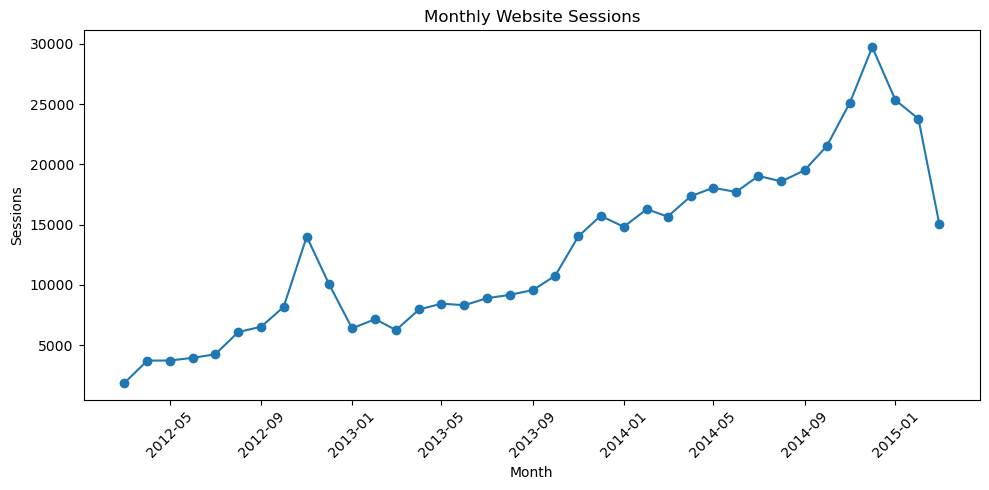

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend["month"],
    monthly_trend["sessions"],
    marker="o"
)

plt.title("Monthly Website Sessions")
plt.xlabel("Month")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

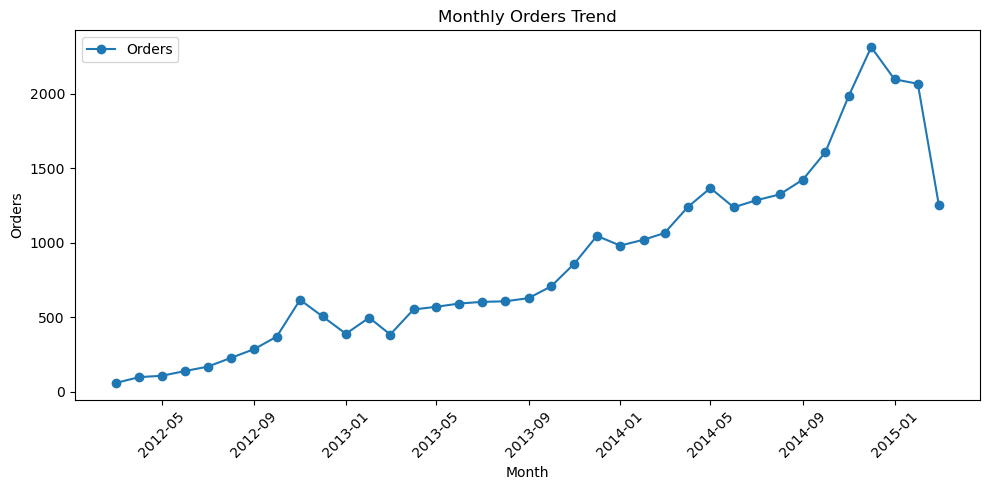

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend["month"],
    monthly_trend["orders"],
    marker="o",
    label="Orders"
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

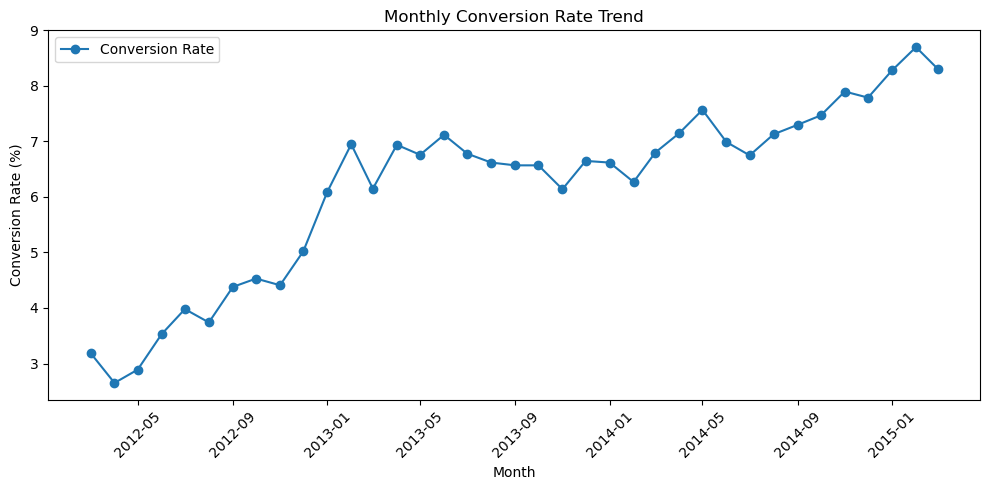

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend["month"],
    monthly_trend["conversion_rate_pct"],
    marker="o",
    label="Conversion Rate"
)

plt.title("Monthly Conversion Rate Trend")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

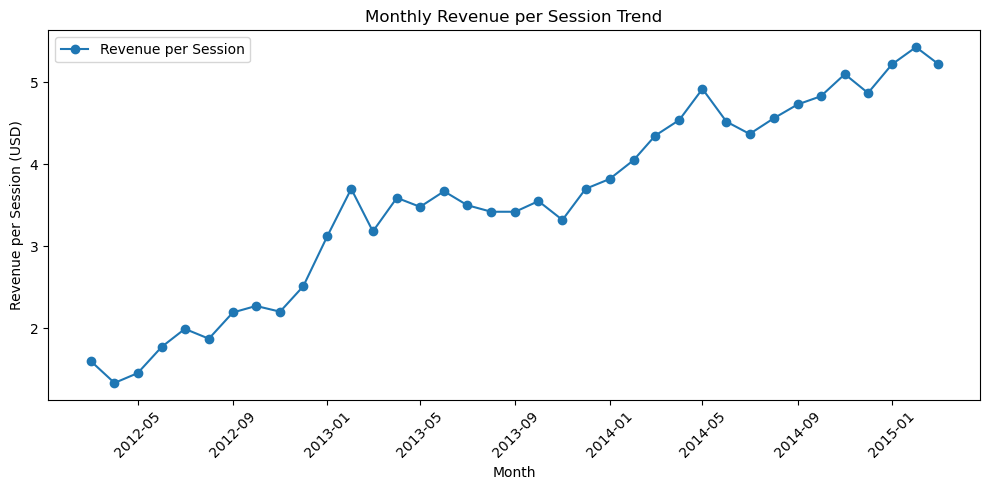

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend["month"],
    monthly_trend["revenue_per_session"],
    marker="o",
    label="Revenue per Session"
)

plt.title("Monthly Revenue per Session Trend")
plt.xlabel("Month")
plt.ylabel("Revenue per Session (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

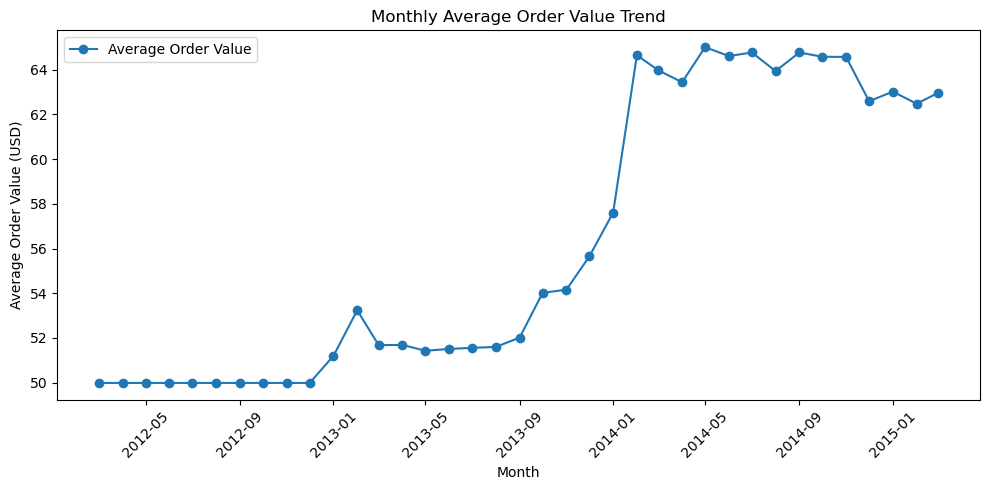

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend["month"],
    monthly_trend["average_order_value"],
    marker="o",
    label="Average Order Value"
)

plt.title("Monthly Average Order Value Trend")
plt.xlabel("Month")
plt.ylabel("Average Order Value (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
order_items["month"] = order_items["created_at"].dt.to_period("M").dt.to_timestamp()

In [22]:
items_per_order = (
    order_items
    .groupby(["month", "order_id"])
    .agg(items_in_order=("order_item_id", "count"))
    .reset_index()
)

In [24]:
monthly_items_per_order = (
    items_per_order
    .groupby("month")
    .agg(avg_items_per_order=("items_in_order", "mean"))
    .reset_index()
)

monthly_items_per_order["avg_items_per_order"] = monthly_items_per_order["avg_items_per_order"].round(2)

monthly_items_per_order.head(10)

,month,avg_items_per_order
0,2012-03-01,1.0
1,2012-04-01,1.0
2,2012-05-01,1.0
3,2012-06-01,1.0
4,2012-07-01,1.0
5,2012-08-01,1.0
6,2012-09-01,1.0
7,2012-10-01,1.0
8,2012-11-01,1.0
9,2012-12-01,1.0


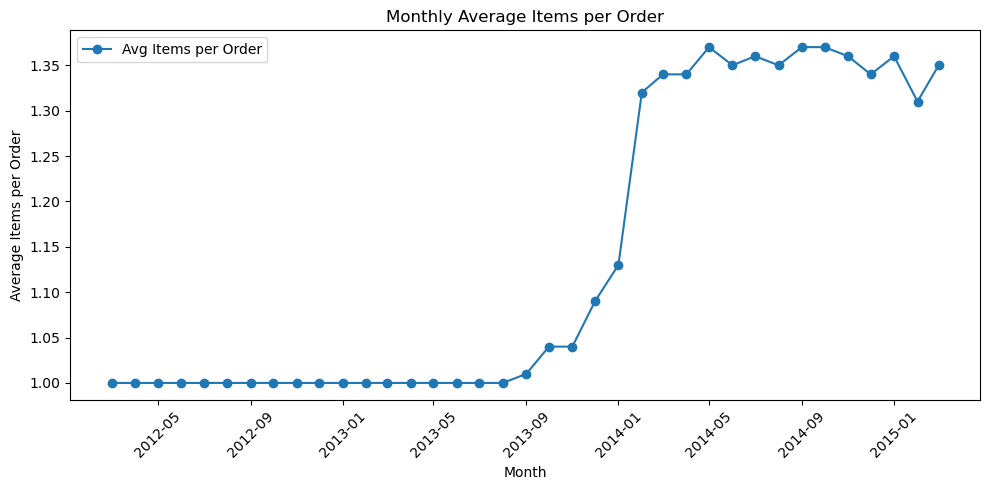

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_items_per_order["month"],
    monthly_items_per_order["avg_items_per_order"],
    marker="o",
    label="Avg Items per Order"
)

plt.title("Monthly Average Items per Order")
plt.xlabel("Month")
plt.ylabel("Average Items per Order")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
order_items_products = order_items.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

monthly_product_sales = (
    order_items_products
    .groupby(["month", "product_name"])
    .agg(
        items_sold=("order_item_id", "count"),
        gross_revenue=("price_usd", "sum")
    )
    .reset_index()
)

monthly_product_sales["gross_revenue"] = monthly_product_sales["gross_revenue"].round(2)

monthly_product_sales.head(20)

,month,product_name,items_sold,gross_revenue
0,2012-03-01,The Original Mr. Fuzzy,60,2999.40
1,2012-04-01,The Original Mr. Fuzzy,99,4949.01
2,2012-05-01,The Original Mr. Fuzzy,108,5398.92
3,2012-06-01,The Original Mr. Fuzzy,140,6998.60
4,2012-07-01,The Original Mr. Fuzzy,169,8448.31
5,2012-08-01,The Original Mr. Fuzzy,228,11397.72
6,2012-09-01,The Original Mr. Fuzzy,287,14347.13
7,2012-10-01,The Original Mr. Fuzzy,371,18546.29
8,2012-11-01,The Original Mr. Fuzzy,618,30893.82
9,2012-12-01,The Original Mr. Fuzzy,506,25294.94


In [27]:
monthly_product_pivot = monthly_product_sales.pivot(
    index="month",
    columns="product_name",
    values="items_sold"
).fillna(0)

monthly_product_pivot.head(15)

product_name,The Birthday Sugar Panda,The Forever Love Bear,The Hudson River Mini bear,The Original Mr. Fuzzy
month,,,,
2012-03-01,0.0,0.0,0.0,60.0
2012-04-01,0.0,0.0,0.0,99.0
2012-05-01,0.0,0.0,0.0,108.0
2012-06-01,0.0,0.0,0.0,140.0
2012-07-01,0.0,0.0,0.0,169.0
2012-08-01,0.0,0.0,0.0,228.0
2012-09-01,0.0,0.0,0.0,287.0
2012-10-01,0.0,0.0,0.0,371.0
2012-11-01,0.0,0.0,0.0,618.0


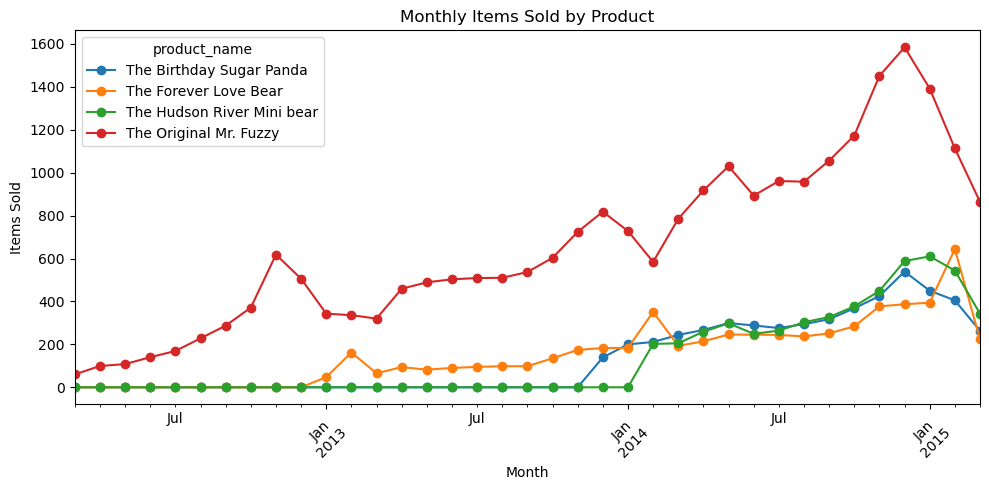

In [28]:
monthly_product_pivot.plot(figsize=(10, 5), marker="o")

plt.title("Monthly Items Sold by Product")
plt.xlabel("Month")
plt.ylabel("Items Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
monthly_product_sales["total_items_month"] = monthly_product_sales.groupby("month")["items_sold"].transform("sum")

monthly_product_sales["product_share_pct"] = (
    monthly_product_sales["items_sold"] / monthly_product_sales["total_items_month"] * 100
).round(2)

monthly_product_share_pivot = monthly_product_sales.pivot(
    index="month",
    columns="product_name",
    values="product_share_pct"
).fillna(0)

monthly_product_share_pivot.head(15)

product_name,The Birthday Sugar Panda,The Forever Love Bear,The Hudson River Mini bear,The Original Mr. Fuzzy
month,,,,
2012-03-01,0.0,0.00,0.0,100.00
2012-04-01,0.0,0.00,0.0,100.00
2012-05-01,0.0,0.00,0.0,100.00
2012-06-01,0.0,0.00,0.0,100.00
2012-07-01,0.0,0.00,0.0,100.00
2012-08-01,0.0,0.00,0.0,100.00
2012-09-01,0.0,0.00,0.0,100.00
2012-10-01,0.0,0.00,0.0,100.00
2012-11-01,0.0,0.00,0.0,100.00


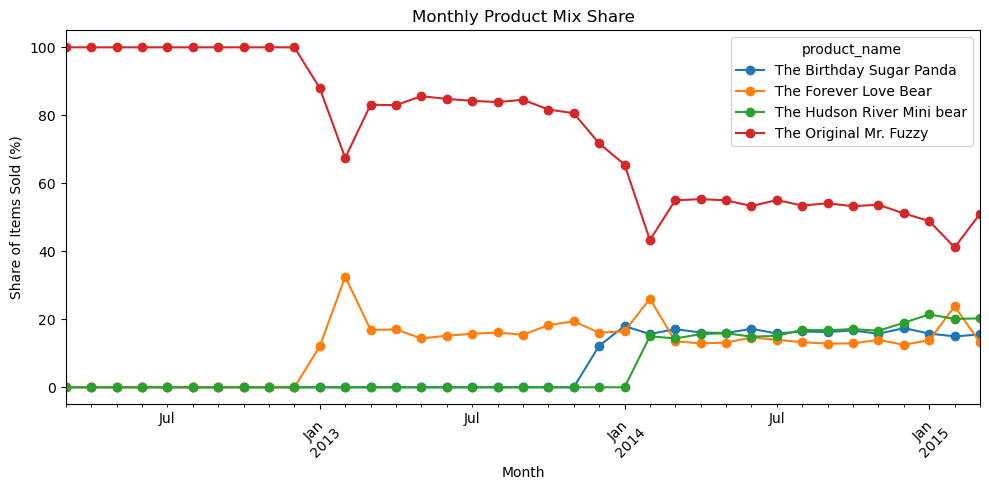

In [30]:
monthly_product_share_pivot.plot(figsize=(10, 5), marker="o")

plt.title("Monthly Product Mix Share")
plt.xlabel("Month")
plt.ylabel("Share of Items Sold (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
product_refunds = (
    order_items
    .merge(
        products[["product_id", "product_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        refunds[["order_item_id", "refund_amount_usd"]],
        on="order_item_id",
        how="left"
    )
)

In [32]:
product_refunds["is_refunded"] = product_refunds["refund_amount_usd"].notna().astype(int)
product_refunds["refund_amount_usd"] = product_refunds["refund_amount_usd"].fillna(0)

In [33]:
product_refund_summary = (
    product_refunds
    .groupby("product_name")
    .agg(
        items_sold=("order_item_id", "count"),
        refunded_items=("is_refunded", "sum"),
        gross_revenue=("price_usd", "sum"),
        refund_amount=("refund_amount_usd", "sum")
    )
    .reset_index()
)

product_refund_summary["item_refund_rate_pct"] = (
    product_refund_summary["refunded_items"] 
    / product_refund_summary["items_sold"] 
    * 100
)

product_refund_summary["net_revenue"] = (
    product_refund_summary["gross_revenue"] 
    - product_refund_summary["refund_amount"]
)

product_refund_summary[[
    "gross_revenue",
    "refund_amount",
    "item_refund_rate_pct",
    "net_revenue"
]] = product_refund_summary[[
    "gross_revenue",
    "refund_amount",
    "item_refund_rate_pct",
    "net_revenue"
]].round(2)

product_refund_summary.sort_values("item_refund_rate_pct", ascending=False)

,product_name,items_sold,refunded_items,gross_revenue,refund_amount,item_refund_rate_pct,net_revenue
0,The Birthday Sugar Panda,4985,301,229260.15,13842.99,6.04,215417.16
3,The Original Mr. Fuzzy,24226,1237,1211057.74,61837.63,5.11,1149220.11
1,The Forever Love Bear,5796,129,347702.04,7738.71,2.23,339963.33
2,The Hudson River Mini bear,5018,64,150489.82,1919.36,1.28,148570.46


# Key Insights from Python EDA

## 1. Business growth drivers
Business growth is driven by a combination of traffic growth, improving conversion rate, and increasing average order value. Sessions and orders grow together, but conversion rate also improves over time.

## 2. Monetization efficiency
Revenue per session increases over time, which means the business is not only attracting more traffic, but also monetizing each visit more effectively.

## 3. AOV growth explanation
Average order value increases significantly around early 2014. This aligns with growth in average items per order, suggesting that customers started buying larger baskets.

## 4. Product mix diversification
The product mix becomes more diversified over time. The Original Mr. Fuzzy starts as the dominant product, but other products gain share later in the dataset.

## 5. Product and refund risk
The Original Mr. Fuzzy is the main revenue driver. The Birthday Sugar Panda has the highest refund rate and should be treated as the main refund-risk product. The Forever Love Bear has solid revenue and a relatively lower refund rate.